In [1]:
import json
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import scipy.io as sio
from sklearn.decomposition import PCA
from statistical_testing_utils import *
from matplotlib.ticker import FormatStrFormatter

Loading the completed neuron selectivity analysis from the pre-generated npy files in `data_neural` (generated by `analysis_neural_2024_selectivity.ipynb`)

In [2]:
dataset_prefix = "diego_new"
neurons_info = sio.loadmat("data_neural_raw/2024_dataset/neurons_info.mat", simplify_cells=True)['neurons']
data_from = [neuron['area_probe_based_str'] for neuron in neurons_info]

area = "MST"  # options: MST, PFC
add_lasertest = False  # add trials with optogenetic manipulation (doesn't affect the cue or delay periods)

N_neurons_allareas = len(neurons_info)
ids_of_area_neurons = []
for i in range(N_neurons_allareas):
    if area != "ALL":
        if area == "LPFC" or area == "PFC":
            if data_from[i] != "PFCL" and data_from[i] != "PFCR": continue
        else:
            if data_from[i] != area: continue
    ids_of_area_neurons.append(i)
N_neurons = len(ids_of_area_neurons)

n_conditions = 4  # 4 stimulus directions (up, down, left, right)
# bin size: 50 ms, step: 50 ms
# fixation: 0-1000ms
# cue: 1000-1800 ms
# delay: 1800-5000ms
# removing first 200 ms of delay
cue_from, cue_to = 20, 36
delay_from, delay_to = 40, 100
fixation_from, fixation_to = 0, 20
def get_neuron_data_for_neuron(neuron_index, remove_nan=True):
    """
        Extract the data for a given neuron (by neuron_index) from the relevant file.
        if remove_nan, removes all NaN-containing trials
        returns neuron_data (n_conditions, number_of_trials, number_of_timesteps)
    """
    neuron_info = neurons_info[ids_of_area_neurons[neuron_index]]
    neuron_data_filename = "data_neural_raw/2024_dataset/Firing_rates_structures/" + neuron_info['folder'] + "/" + neuron_info['filename']
    neuron_data = sio.loadmat(neuron_data_filename, simplify_cells=True)['firing_rate_structure']

    directions = []
    for j in range(7, 11):
        directions.append(np.array(neuron_data['conditions'][j]['binned_firing_rates']).reshape(-1, 180))
        if add_lasertest and (neuron_info['conditions_trials_N'][j+8] > 0):  # add laser ON at test trials, if there were any
            directions[-1] = np.concatenate([directions[-1], np.array(neuron_data['conditions'][j+8]['binned_firing_rates']).reshape(-1, 180)])
    return directions
dataset_specific_args = (get_neuron_data_for_neuron, N_neurons, n_conditions, cue_from, cue_to, delay_from, delay_to)

In [4]:
filename = 'data_neural/diego_2024_pvalues.npz'
print("Loading data from file:", filename)

# Load the variables from the file
loaded_data = np.load(filename)
pval_cue = loaded_data['pval_cue']
pval_delay = loaded_data['pval_delay']
pref_angle_cue = loaded_data['pref_angle_cue']
pref_angle_delay = loaded_data['pref_angle_delay']
n_trials = loaded_data['n_trials']

Loading data from file: data_neural/diego_2024_pvalues.npz


# Determining selective neurons
On one hand, we're doing multiple statistical tests here (one for every neuron). However, on the other hand, we're analyzing neurons who were selective in both the cue and delay period. Instead of trying to correct for this interplay, we choose to calculate type I error in the following way: run our analysis multiple times on reshuffled data, and confirm that the number of "selected" neurons is at most 5% of what it was in non-reshuffled data.

In [5]:
import math
alpha_threshold=0.005

cue_selective, delay_selective, both_selective = determine_selective_neuron_groups(pval_cue, pval_delay, n_trials, alpha_threshold=alpha_threshold)
either_selective = list(set(cue_selective+delay_selective))

print("BOTH_SELECTIVE:")
print(f"At alpha_threshold={alpha_threshold}, we have selected {len(both_selective)} neurons.")

print("\nEITHER_SELECTIVE:")
print(f"At alpha_threshold={alpha_threshold}, we have selected {len(either_selective)} neurons.")

BOTH_SELECTIVE:
At alpha_threshold=0.005, we have selected 64 neurons.

EITHER_SELECTIVE:
At alpha_threshold=0.005, we have selected 672 neurons.


# Intertrial correlation analyses

In [6]:
from scipy import stats
def get_delay_pref_diff(neuron_i, neuron_j):
    pref_angle_diff = np.abs(pref_angle_delay[neuron_i]-pref_angle_delay[neuron_j]) / np.pi * 180
    if pref_angle_diff > 180: pref_angle_diff = 360 - pref_angle_diff
    return pref_angle_diff
def get_preferred_orientation_relative_to_stimulus(neuron_i, stimulus_theta):
    pref_angle_diff = (pref_angle_delay[neuron_i]-stimulus_theta) / np.pi * 180
    while pref_angle_diff > 180: pref_angle_diff -=360
    while pref_angle_diff < -180: pref_angle_diff +=360
    return pref_angle_diff

In [9]:
fixation_ms = 0, 1000
cue_ms = 1000, 1800
delay_ms = 2000, 5000

period_name = "delay"  # "fixation", "cue", "delay"
pairs_name = "inverting"  # "all", "stable", "inverting", "inter"
indices = delay_selective

def calculate_pairwise_correlations(period_name = "delay", pairs_name = "all", split_by_stimulus_direction = False, indices = delay_selective):
    """
        period_name could be: "fixation", "cue", "delay"
        pairs_name could be: "all", "stable", "inverting", "inter"
        
        Calculates inter-trial pairwise spike count correlation in a given task window, 
        as a function of the difference in preferred direction of the pair of neurons
        Returns two numpy arrays: array_pref_diffs, array_corrs
    """
    array_pref_diffs = []
    array_corrs = []
    BIN_MS = 50
    if period_name == "fixation":
        cut_from, cut_to = fixation_ms
    elif period_name == "cue":
        cut_from, cut_to = cue_ms
    elif period_name == "delay":
        cut_from, cut_to = delay_ms
    pref_angle_diff = np.copy(pref_angle_cue-pref_angle_delay) / np.pi * 180
    pref_angle_diff = np.abs(pref_angle_diff)
    pref_angle_diff[pref_angle_diff>180] = 360 - pref_angle_diff[pref_angle_diff>180]
    for i in indices:
        for j in indices:
            if i>=j: continue  # only take pairs of neurons (i, j) where i<j
    
            if pairs_name == "stable":  # only include pairs of stable neurons
                if pref_angle_diff[i] > 90: continue
                if pref_angle_diff[j] > 90: continue
            elif pairs_name == "inverting":  # only include pairs of inverting neurons
                if pref_angle_diff[i] < 90: continue
                if pref_angle_diff[j] < 90: continue
            elif pairs_name == "inter":  # only include pairs where one is stable and the other one is inverting
                if (pref_angle_diff[i] < 90) and (pref_angle_diff[j] < 90): continue
                if (pref_angle_diff[i] > 90) and (pref_angle_diff[j] > 90): continue
                
            neuron_i_info = neurons_info[ids_of_area_neurons[i]]
            neuron_j_info = neurons_info[ids_of_area_neurons[j]]
            if neuron_i_info['folder'] != neuron_j_info['folder']: continue  # only take neuron pairs from the same session
            pref_i = pref_angle_delay[i]
            pref_j = pref_angle_delay[j]
    
            neuron_data_filename = "data_neural_raw/2024_dataset/Firing_rates_structures/" + neuron_i_info['folder'] + "/" + neuron_i_info['filename']
            neuron_i_data = sio.loadmat(neuron_data_filename, simplify_cells=True)['firing_rate_structure']
            neuron_data_filename = "data_neural_raw/2024_dataset/Firing_rates_structures/" + neuron_j_info['folder'] + "/" + neuron_j_info['filename']
            neuron_j_data = sio.loadmat(neuron_data_filename, simplify_cells=True)['firing_rate_structure']
    
            neuron_i_spikes = neuron_i_data['no_condition']['data']
            neuron_j_spikes = neuron_j_data['no_condition']['data']
            n_trials_i = neuron_i_spikes.shape[0]
            n_trials_j = neuron_j_spikes.shape[0]
            assert n_trials_i==n_trials_j
            n_trials = n_trials_i

            if split_by_stimulus_direction:
                for dir_i in range(7, 11):
                    trials_i = neuron_i_data['conditions'][dir_i]['original_trial_numbers']
                    trials_j = neuron_j_data['conditions'][dir_i]['original_trial_numbers']
                    trials_ids_i = [x_i for x_i, x in enumerate(trials_i) if x in trials_j]
                    trials_ids_j = [x_i for x_i, x in enumerate(trials_j) if x in trials_i]
                    trials_both_ids = [x for x in trials_i if x in trials_j]
                    if len(trials_both_ids)<2: continue  
                    #print([len(x) for x in [trials_i, trials_j, trials_both_ids]])
        
                    neuron_i_spikes_cut_and_binned = neuron_i_data['conditions'][dir_i]['binned_firing_rates'][trials_ids_i, :][:, cut_from//BIN_MS:cut_to//BIN_MS]
                    neuron_j_spikes_cut_and_binned = neuron_j_data['conditions'][dir_i]['binned_firing_rates'][trials_ids_j, :][:, cut_from//BIN_MS:cut_to//BIN_MS]
                    neuron_i_spikes_cut_and_binned = np.sum(neuron_i_spikes_cut_and_binned, axis=1)  # collapse to mean over period
                    neuron_j_spikes_cut_and_binned = np.sum(neuron_j_spikes_cut_and_binned, axis=1)
        
                    if np.var(neuron_i_spikes_cut_and_binned) == 0: continue
                    if np.var(neuron_j_spikes_cut_and_binned) == 0: continue

                    corr = np.corrcoef(neuron_i_spikes_cut_and_binned, neuron_j_spikes_cut_and_binned)[1, 0]
                    array_pref_diffs.append(get_delay_pref_diff(i, j))
                    array_corrs.append(np.mean(corr))
            else:
                neuron_i_spikes_cut_and_binned = np.sum(neuron_i_data['no_condition']['data'][:, cut_from:cut_to].reshape(n_trials, (cut_to-cut_from)//BIN_MS, BIN_MS), axis=2)
                neuron_j_spikes_cut_and_binned = np.sum(neuron_j_data['no_condition']['data'][:, cut_from:cut_to].reshape(n_trials, (cut_to-cut_from)//BIN_MS, BIN_MS), axis=2)
                neuron_i_spikes_cut_and_binned = np.sum(neuron_i_spikes_cut_and_binned, axis=1)  # collapse to mean over period
                neuron_j_spikes_cut_and_binned = np.sum(neuron_j_spikes_cut_and_binned, axis=1)
                
                corr = np.corrcoef(neuron_i_spikes_cut_and_binned, neuron_j_spikes_cut_and_binned)[1, 0]
                array_pref_diffs.append(get_delay_pref_diff(i, j))
                array_corrs.append(corr)
    return np.array(array_pref_diffs), np.array(array_corrs)
    
def plot_pairwise_correlations_raw(period_name = "delay", pairs_name = "all", split_by_stimulus_direction = False, indices = delay_selective, array_pref_diffs=None, array_corrs=None):   
    if (array_pref_diffs is None) or (array_corrs is None):
        array_pref_diffs, array_corrs = calculate_pairwise_correlations(period_name, pairs_name, split_by_stimulus_direction, indices)

    # Set figure properties
    plt.rc('font', **{'family': 'Arial', 'weight': 'normal', 'size': 14})
    fig = plt.figure(figsize=(6, 4))
    
    # plot points in bg
    plt.scatter(array_pref_diffs, array_corrs, color="black", alpha=.2, rasterized=True)
    # plot horizontal corr=0 line
    plt.axhline(0, color="black", linestyle="--", linewidth=3)

    # Bin settings
    bin_width = 45
    bins = np.array([0, 45, 135, 180])
    bin_means, bin_edges, _ = stats.binned_statistic(array_pref_diffs, array_corrs, statistic='mean', bins=bins)
    #plot vertical edge lines
    for bin_edge in bin_edges:
        plt.axvline(bin_edge, color="black", linestyle="--", linewidth=1)
    
    # Additional plot settings
    plt.ylim(-1.1, 1.1)
    plt.xticks(np.linspace(0, 180, 5))
    plt.xlim(-5, 185)
    plt.xlabel("absolute difference in preferred stimulus direction\nof two neurons (calculated during delay)")
    plt.gca().xaxis.set_major_formatter(FormatStrFormatter('%d°'))
    plt.ylabel("correlation of spike numbers\nof two neurons across all trials"+("\n(split by stimulus direction)" if split_by_stimulus_direction else ""))
    #plt.title(f"Spike numbers during {period_name} period\nConsidering pairs from: {pairs_name} cluster")
    
    plt.tight_layout()
    plt.savefig(f'paper_figures/{dataset_prefix}_{area.lower()}_intertrialcorr_{period_name}_{pairs_name}_split{split_by_stimulus_direction}_raw.pdf', bbox_inches="tight")

def plot_pairwise_correlations_averaged(period_name = "delay", pairs_name = "all", split_by_stimulus_direction = False, indices = delay_selective, array_pref_diffs=None, array_corrs=None):   
    if (array_pref_diffs is None) or (array_corrs is None):
        array_pref_diffs, array_corrs = calculate_pairwise_correlations(period_name, pairs_name, split_by_stimulus_direction, indices)

    # Set figure properties
    fig = plt.figure(figsize=(6, 4))
    plt.rc('font', **{'family': 'Arial', 'weight': 'normal', 'size': 14})
    
    # Bin settings
    bin_width = 45
    bins = np.arange(0, max(array_pref_diffs) + bin_width, bin_width)
    bins = np.array([0, 45, 135, 180])
    bin_means, bin_edges, _ = stats.binned_statistic(array_pref_diffs, array_corrs, statistic='mean', bins=bins)
    bin_std, _, _ = stats.binned_statistic(array_pref_diffs, array_corrs, statistic='std', bins=bins)
    bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
    bin_sem = bin_std / np.sqrt(np.histogram(array_pref_diffs, bins)[0]-1)  # Calculate SEM
    
    # plot points in bg
    plt.scatter(array_pref_diffs, array_corrs, color="lightgray", alpha=.3, rasterized=True)
    # Plotting error bars for each bin
    plt.errorbar(bin_centers, bin_means, yerr=bin_sem, color='black', ecolor='black', linewidth=3, elinewidth=3, capsize=10)
    #plot vertical edge lines
    for bin_edge in bin_edges:
        plt.axvline(bin_edge, color="black", linestyle="--", linewidth=1)
    # plot horizontal corr=0 line
    plt.axhline(0, color="black", linestyle="--", linewidth=3)
    # Calculate and add p-values with staggered heights
    max_height = max(bin_means) + max(bin_sem)
    y_offset = max_height * 0.05
    padding = y_offset * 1.5  # Add padding between brackets
    bracket_heights = {}

    ax = plt.gca()
    def add_pvalue(i, j):
        group1 = array_corrs[(array_pref_diffs >= bin_edges[i]) & (array_pref_diffs < bin_edges[i+1])]
        group2 = array_corrs[(array_pref_diffs >= bin_edges[j]) & (array_pref_diffs < bin_edges[j+1])]
        _, p_value = stats.ttest_ind(group1, group2)
        
        x = (bin_centers[i] + bin_centers[j]) / 2
        base_height = max(bin_means)+max(bin_sem)#max(bin_means[i], bin_means[j]) + max(bin_sem[i], bin_sem[j])
        
        height_multiplier = 1
        while any(abs(x - ex) < 45 and abs(base_height + height_multiplier * y_offset - ey) < (y_offset + padding)
                  for ex, ey in bracket_heights.values()):
            height_multiplier += 1

        y = base_height + height_multiplier * y_offset
        bracket_heights[(i, j)] = (x, y)
        
        # Format p-value string
        p_str = "p<0.001" if p_value < 0.001 else f"p={p_value:.3f}"
        
        ax.text(x, y + y_offset/2, p_str, ha='center', va='bottom', fontsize=14)
        ax.plot([bin_centers[i], bin_centers[i], bin_centers[j], bin_centers[j]],
                [y-y_offset/2, y, y, y-y_offset/2], color='black', linewidth=2)

    for i in range(len(bin_centers)):
        for j in range(i+1, len(bin_centers)):
            add_pvalue(i, j)

    # Additional plot settings
    ax.set_ylim(-0.1, max(y for _, y in bracket_heights.values()) + y_offset * 3)
    plt.xticks(np.linspace(0, 180, 5))
    plt.xlim(-5, 185)
    plt.xlabel("absolute difference in preferred stimulus direction\nof two neurons (calculated during delay)")
    plt.gca().xaxis.set_major_formatter(FormatStrFormatter('%d°'))
    plt.ylabel("correlation of spike numbers\nof two neurons across all trials"+("\n(split by stimulus direction)" if split_by_stimulus_direction else ""))
    #plt.title(f"Spike numbers during {period_name} period\nConsidering pairs from: {pairs_name} cluster")

    plt.tight_layout()
    figure_name = f'paper_figures/{dataset_prefix}_{area.lower()}_intertrialcorr_{period_name}_{pairs_name}_split{split_by_stimulus_direction}_averaged.pdf'
    plt.savefig(figure_name, bbox_inches='tight')
    print(f"{figure_name}: N={len(array_pref_diffs)}")

def plot_pairwise_correlations_averaged_bar(period_name="delay", pairs_name="all", split_by_stimulus_direction=False, indices=delay_selective, array_pref_diffs=None, array_corrs=None):   
    if (array_pref_diffs is None) or (array_corrs is None):
        array_pref_diffs, array_corrs = calculate_pairwise_correlations(period_name, pairs_name, split_by_stimulus_direction, indices)

    # Set figure properties
    fig, ax = plt.subplots(figsize=(6, 4))
    plt.rc('font', **{'family': 'Arial', 'weight': 'normal', 'size': 14})
    
    # Bin settings
    bins = np.array([0, 45, 135, 180])
    bin_means, bin_edges, _ = stats.binned_statistic(array_pref_diffs, array_corrs, statistic='mean', bins=bins)
    bin_std, _, _ = stats.binned_statistic(array_pref_diffs, array_corrs, statistic='std', bins=bins)
    bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
    bin_sem = bin_std / np.sqrt(np.histogram(array_pref_diffs, bins)[0]-1)
    
    # Create bar plot
    ax.bar(bin_centers, bin_means, width=45, align='center', color='lightgray', edgecolor='black')
    ax.errorbar(bin_centers, bin_means, yerr=bin_sem, color='black', ecolor='black', fmt='none', capsize=10, capthick=2, elinewidth=2)
    ax.axhline(0, color="black", linestyle="--", linewidth=2)
    
    # Calculate and add p-values with staggered heights
    max_height = max(bin_means) + max(bin_sem)
    y_offset = max_height * 0.05
    padding = y_offset * 1.5  # Add padding between brackets
    bracket_heights = {}

    def add_pvalue(i, j):
        group1 = array_corrs[(array_pref_diffs >= bin_edges[i]) & (array_pref_diffs < bin_edges[i+1])]
        group2 = array_corrs[(array_pref_diffs >= bin_edges[j]) & (array_pref_diffs < bin_edges[j+1])]
        _, p_value = stats.ttest_ind(group1, group2)
        
        x = (bin_centers[i] + bin_centers[j]) / 2
        base_height = max(bin_means)+max(bin_sem)#max(bin_means[i], bin_means[j]) + max(bin_sem[i], bin_sem[j])
        
        height_multiplier = 1
        while any(abs(x - ex) < 45 and abs(base_height + height_multiplier * y_offset - ey) < (y_offset + padding)
                  for ex, ey in bracket_heights.values()):
            height_multiplier += 1

        y = base_height + height_multiplier * y_offset
        bracket_heights[(i, j)] = (x, y)
        
        # Format p-value string
        p_str = "p<0.001" if p_value < 0.001 else f"p={p_value:.3f}"
        
        ax.text(x, y + y_offset/2, p_str, ha='center', va='bottom', fontsize=14)
        ax.plot([bin_centers[i], bin_centers[i], bin_centers[j], bin_centers[j]],
                [y-y_offset/2, y, y, y-y_offset/2], color='black', linewidth=2)

    for i in range(len(bin_centers)):
        for j in range(i+1, len(bin_centers)):
            add_pvalue(i, j)

    # Additional plot settings
    ax.set_ylim(-0.1, max(y for _, y in bracket_heights.values()) + y_offset * 3)
    ax.set_xlim(-5, 185)
    ax.set_xticks(bin_centers)
    ax.set_xticklabels([f"{int(bin_edges[i])}-{int(bin_edges[i+1])}°" for i in range(len(bin_edges)-1)])
    ax.set_xlabel("absolute difference in preferred stimulus direction\nof two neurons (calculated during delay)")
    ax.set_ylabel("correlation of spike numbers\nof two neurons across all trials" + 
                  ("\n(split by stimulus direction)" if split_by_stimulus_direction else ""))

    plt.tight_layout()

    figure_name = f'paper_figures/{dataset_prefix}_{area.lower()}_intertrialcorr_{period_name}_{pairs_name}_split{split_by_stimulus_direction}_averaged_bar.pdf'
    print(f"{figure_name}: N={len(array_pref_diffs)}")
    plt.savefig(figure_name, bbox_inches='tight')

In [10]:
period_name = "delay"
pairs_name = "all"
split_by_stimulus_direction = False
array_pref_diffs, array_corrs = calculate_pairwise_correlations(period_name, pairs_name, split_by_stimulus_direction, indices)

In [ ]:
for period_name in ["fixation", "delay"]:
    for pairs_name in ["all", "stable", "inverting", "inter"]:
        for split_by_stimulus_direction in ([True] if period_name == "delay" else [False]):
            array_pref_diffs, array_corrs = calculate_pairwise_correlations(period_name, pairs_name, split_by_stimulus_direction, indices)
            plot_pairwise_correlations_raw(period_name, pairs_name, split_by_stimulus_direction, indices, array_pref_diffs, array_corrs)
            plt.clf()
            plot_pairwise_correlations_averaged(period_name, pairs_name, split_by_stimulus_direction, indices, array_pref_diffs, array_corrs)
            plt.clf()
            plot_pairwise_correlations_averaged_bar(period_name, pairs_name, split_by_stimulus_direction, indices, array_pref_diffs, array_corrs)
            plt.clf()

# Noise correlation for stimulus in-flank, peaks, out-flanks


## Fixation period correlation

In [13]:
fixation_ms = 0, 1000
cue_ms = 1000, 1800
delay_ms = 2000, 5000

allow_peaks_angle = 7.5

period_name = "fixation"  # "fixation", "cue", "delay"
indices = cue_selective if period_name == "cue" else delay_selective

array_pref_diffs = []
array_corrs = []
if period_name == "cue":
    cut_from, cut_to = cue_from, cue_to
    pref_angle_array = pref_angle_cue
elif period_name == "delay":
    cut_from, cut_to = delay_from, delay_to
    pref_angle_array = pref_angle_delay
elif period_name == "fixation":
    cut_from, cut_to = fixation_from, fixation_to #//3 # uncomment for third of fixation period
    pref_angle_array = pref_angle_delay


stim_direction_array = []
noise_correlation_array = []
pref_dir_diff_array = []
neuron_ids_array = []

for i in indices:
    for j in indices:
        if i>=j: continue  # only take pairs of neurons (i, j) where i<j
        
        pref_angle_distance = np.abs(pref_angle_array[i]-pref_angle_array[j]).item() * 180/np.pi
        if pref_angle_distance > 180: pref_angle_distance = 360 - pref_angle_distance
        
        pref_dir1 = pref_angle_array[i] * 180/np.pi
        pref_dir2 = pref_angle_array[j] * 180/np.pi
        pref_dir = (pref_dir1 + pref_dir2)/2
            
        neuron_i_info = neurons_info[ids_of_area_neurons[i]]
        neuron_j_info = neurons_info[ids_of_area_neurons[j]]
        if neuron_i_info['folder'] != neuron_j_info['folder']: continue  # only take neuron pairs from the same session
        neuron_data_filename = "data_neural_raw/2024_dataset/Firing_rates_structures/" + neuron_i_info['folder'] + "/" + neuron_i_info['filename']
        neuron_i_data = sio.loadmat(neuron_data_filename, simplify_cells=True)['firing_rate_structure']
        neuron_data_filename = "data_neural_raw/2024_dataset/Firing_rates_structures/" + neuron_j_info['folder'] + "/" + neuron_j_info['filename']
        neuron_j_data = sio.loadmat(neuron_data_filename, simplify_cells=True)['firing_rate_structure']

        neuron_i_spikes = neuron_i_data['no_condition']['data']
        neuron_j_spikes = neuron_j_data['no_condition']['data']
        n_trials_i = neuron_i_spikes.shape[0]
        n_trials_j = neuron_j_spikes.shape[0]
        assert n_trials_i==n_trials_j
        n_trials = n_trials_i

        for dir_i in range(7, 11):
            trials_i = neuron_i_data['conditions'][dir_i]['original_trial_numbers']
            trials_j = neuron_j_data['conditions'][dir_i]['original_trial_numbers']
            trials_ids_i = [x_i for x_i, x in enumerate(trials_i) if x in trials_j]
            trials_ids_j = [x_i for x_i, x in enumerate(trials_j) if x in trials_i]
            trials_both_ids = [x for x in trials_i if x in trials_j]
            if len(trials_both_ids)<2: continue  
            #print([len(x) for x in [trials_i, trials_j, trials_both_ids]])

            neuron_i_spikes_cut_and_binned = neuron_i_data['conditions'][dir_i]['binned_firing_rates'][trials_ids_i, :][:, cut_from:cut_to]
            neuron_j_spikes_cut_and_binned = neuron_j_data['conditions'][dir_i]['binned_firing_rates'][trials_ids_j, :][:, cut_from:cut_to]
            neuron_i_spikes_cut_and_binned = np.sum(neuron_i_spikes_cut_and_binned, axis=1)  # collapse to mean over period
            neuron_j_spikes_cut_and_binned = np.sum(neuron_j_spikes_cut_and_binned, axis=1)

            if np.var(neuron_i_spikes_cut_and_binned) == 0: continue
            if np.var(neuron_j_spikes_cut_and_binned) == 0: continue

            corr = np.corrcoef(neuron_i_spikes_cut_and_binned, neuron_j_spikes_cut_and_binned)[1, 0]

            stim_direction = (dir_i-7) * 90 - pref_dir
            if stim_direction > 180: stim_direction = stim_direction - 360
            if stim_direction < -180: stim_direction = stim_direction + 360

            # Normalize angles to -180 to +180 range
            pref_dir1_norm = ((pref_dir1 + 180) % 360) - 180
            pref_dir2_norm = ((pref_dir2 + 180) % 360) - 180
            stim_dir_norm = ((stim_direction + 180) % 360) - 180
            # Sort the pref directions to have pref_dir1 < pref_dir2
            if pref_dir1_norm > pref_dir2_norm:
                pref_dir1_norm, pref_dir2_norm = pref_dir2_norm, pref_dir1_norm
            # Check if stim direction is between pref directions
            is_between_code = 0
            if min(abs(stim_dir_norm - pref_dir1_norm), abs(stim_dir_norm - pref_dir2_norm)) <= allow_peaks_angle or \
               min(abs(stim_dir_norm - pref_dir1_norm + 360), abs(stim_dir_norm - pref_dir1_norm - 360)) <= allow_peaks_angle or \
               min(abs(stim_dir_norm - pref_dir2_norm + 360), abs(stim_dir_norm - pref_dir2_norm - 360)) <= allow_peaks_angle:
                is_between_code = -1
            elif pref_dir2_norm - pref_dir1_norm <= 180:
                # Normal case - no wrapping around ±180
                is_between_code = int(pref_dir1_norm <= stim_dir_norm <= pref_dir2_norm)
            else:
                # Case where preferred directions wrap around ±180
                # e.g. pref1 = 170, pref2 = -160
                # Then "between" means stim >= pref1 OR stim <= pref2
                is_between_code = int(stim_dir_norm >= pref_dir1_norm or stim_dir_norm <= pref_dir2_norm)
            
            # Calculate absolute difference between preferred directions accounting for wrapping
            pref_dir_diff_array.append(pref_angle_distance)
            neuron_ids_array.append((i, j))
            

            stim_direction_array.append(is_between_code)
            noise_correlation_array.append(corr)

P-values (two-sided t-test against 0):
In-Flank (n=225 pairs): p=2.865e-01
Peaks (n=310 pairs): p=2.854e-14
Out-Flanks (n=791 pairs): p=6.834e-138
All groups combined (n=842 pairs): mean=0.159, SEM=0.006


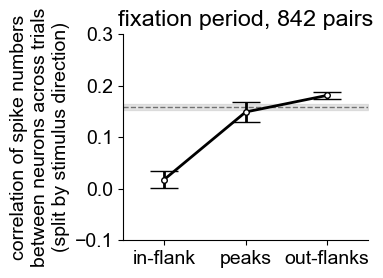

In [14]:
import scipy.stats as stats

# Convert lists to numpy arrays for easier manipulation
stim_direction_array_fixation = np.array(stim_direction_array)
noise_correlation_array_fixation = np.array(noise_correlation_array)

# Calculate means and SEMs for each group
between_corrs_fixation = noise_correlation_array_fixation[stim_direction_array_fixation==1]
peaks_corrs_fixation = noise_correlation_array_fixation[stim_direction_array_fixation==-1]
not_between_corrs_fixation = noise_correlation_array_fixation[stim_direction_array_fixation==0]

between_pairs_fixation = list(set([neuron_ids_array[i] for i in np.where(stim_direction_array_fixation==1)[0]]))
peaks_pairs_fixation = list(set([neuron_ids_array[i] for i in np.where(stim_direction_array_fixation==-1)[0]]))
not_between_pairs_fixation = list(set([neuron_ids_array[i] for i in np.where(stim_direction_array_fixation==0)[0]]))

means_fixation = [np.mean(between_corrs_fixation), np.mean(peaks_corrs_fixation), np.mean(not_between_corrs_fixation)]
sems_fixation = [stats.sem(between_corrs_fixation), stats.sem(peaks_corrs_fixation), stats.sem(not_between_corrs_fixation)]

# Calculate overall mean and SEM
all_pairs_fixation = list(set([pair for pair in neuron_ids_array]))
overall_mean_fixation = np.mean(noise_correlation_array_fixation)
overall_sem_fixation = stats.sem(noise_correlation_array_fixation)

# Calculate p-values using two-sided t-test against 0
p_values_fixation = [stats.ttest_1samp(between_corrs_fixation, 0, alternative='two-sided').pvalue,
            stats.ttest_1samp(peaks_corrs_fixation, 0, alternative='two-sided').pvalue,
            stats.ttest_1samp(not_between_corrs_fixation, 0, alternative='two-sided').pvalue]

print("P-values (two-sided t-test against 0):")
print(f"In-Flank (n={len(between_pairs_fixation)} pairs): p={p_values_fixation[0]:.3e}")
print(f"Peaks (n={len(peaks_pairs_fixation)} pairs): p={p_values_fixation[1]:.3e}")  
print(f"Out-Flanks (n={len(not_between_pairs_fixation)} pairs): p={p_values_fixation[2]:.3e}")
print(f"All groups combined (n={len(all_pairs_fixation)} pairs): mean={overall_mean_fixation:.3f}, SEM={overall_sem_fixation:.3f}")

# Create the plot
fig, ax = plt.subplots(figsize=(4, 3))
plt.rc('font', **{'family': 'Arial', 'weight': 'normal', 'size': 14})
x = np.arange(3)

# Plot individual points with jitter
jitter = np.random.normal(0, 0.07, len(noise_correlation_array_fixation))
plt.ylim(-0.1, 0.3)
plt.xlim(-0.5, 2.5)

# Add horizontal line at overall mean and shaded SEM region
ax.axhline(y=overall_mean_fixation, color='black', linestyle='--', alpha=.5, linewidth=1)
ax.fill_between([-0.5, 2.5], overall_mean_fixation - overall_sem_fixation, overall_mean_fixation + overall_sem_fixation, 
                color='gray', alpha=0.2)

# Plot line with error bars
ax.errorbar(x, means_fixation, yerr=sems_fixation, capsize=10, color='black', marker='.', markersize=8,
           markerfacecolor='white', markeredgecolor='black', linewidth=2)

# Customize the plot
ax.set_title(f"fixation period, {len(all_pairs_fixation)} pairs")
ax.set_xticks(x)
ax.set_xticklabels(['in-flank', 'peaks', 'out-flanks'])
ax.set_ylabel('correlation of spike numbers\nbetween neurons across trials\n(split by stimulus direction)')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('paper_figures/noise_correlation_between_flank_and_peaks_fixation.pdf', bbox_inches='tight')


## Delay period correlation

In [15]:

fixation_ms = 0, 1000
cue_ms = 1000, 1800
delay_ms = 2000, 5000

period_name = "delay"  # "fixation", "cue", "delay"
indices = cue_selective if period_name == "cue" else delay_selective

array_pref_diffs = []
array_corrs = []
if period_name == "cue":
    cut_from, cut_to = cue_from, cue_to
    pref_angle_array = pref_angle_cue
elif period_name == "delay":
    cut_from, cut_to = delay_from, delay_to
    pref_angle_array = pref_angle_delay


stim_direction_array = []
noise_correlation_array = []
pref_dir_diff_array = []
neuron_ids_array = []

for i in indices:
    for j in indices:
        if i>=j: continue  # only take pairs of neurons (i, j) where i<j
        
        pref_angle_distance = np.abs(pref_angle_array[i]-pref_angle_array[j]).item() * 180/np.pi
        if pref_angle_distance > 180: pref_angle_distance = 360 - pref_angle_distance
        
        pref_dir1 = pref_angle_array[i] * 180/np.pi
        pref_dir2 = pref_angle_array[j] * 180/np.pi
        pref_dir = (pref_dir1 + pref_dir2)/2
            
        neuron_i_info = neurons_info[ids_of_area_neurons[i]]
        neuron_j_info = neurons_info[ids_of_area_neurons[j]]
        if neuron_i_info['folder'] != neuron_j_info['folder']: continue  # only take neuron pairs from the same session
        neuron_data_filename = "data_neural_raw/2024_dataset/Firing_rates_structures/" + neuron_i_info['folder'] + "/" + neuron_i_info['filename']
        neuron_i_data = sio.loadmat(neuron_data_filename, simplify_cells=True)['firing_rate_structure']
        neuron_data_filename = "data_neural_raw/2024_dataset/Firing_rates_structures/" + neuron_j_info['folder'] + "/" + neuron_j_info['filename']
        neuron_j_data = sio.loadmat(neuron_data_filename, simplify_cells=True)['firing_rate_structure']

        neuron_i_spikes = neuron_i_data['no_condition']['data']
        neuron_j_spikes = neuron_j_data['no_condition']['data']
        n_trials_i = neuron_i_spikes.shape[0]
        n_trials_j = neuron_j_spikes.shape[0]
        assert n_trials_i==n_trials_j
        n_trials = n_trials_i

        for dir_i in range(7, 11):
            trials_i = neuron_i_data['conditions'][dir_i]['original_trial_numbers']
            trials_j = neuron_j_data['conditions'][dir_i]['original_trial_numbers']
            trials_ids_i = [x_i for x_i, x in enumerate(trials_i) if x in trials_j]
            trials_ids_j = [x_i for x_i, x in enumerate(trials_j) if x in trials_i]
            trials_both_ids = [x for x in trials_i if x in trials_j]
            if len(trials_both_ids)<2: continue  
            #print([len(x) for x in [trials_i, trials_j, trials_both_ids]])

            neuron_i_spikes_cut_and_binned = neuron_i_data['conditions'][dir_i]['binned_firing_rates'][trials_ids_i, :][:, cut_from:cut_to]
            neuron_j_spikes_cut_and_binned = neuron_j_data['conditions'][dir_i]['binned_firing_rates'][trials_ids_j, :][:, cut_from:cut_to]
            neuron_i_spikes_cut_and_binned = np.sum(neuron_i_spikes_cut_and_binned, axis=1)  # collapse to mean over period
            neuron_j_spikes_cut_and_binned = np.sum(neuron_j_spikes_cut_and_binned, axis=1)

            if np.var(neuron_i_spikes_cut_and_binned) == 0: continue
            if np.var(neuron_j_spikes_cut_and_binned) == 0: continue

            corr = np.corrcoef(neuron_i_spikes_cut_and_binned, neuron_j_spikes_cut_and_binned)[1, 0]

            stim_direction = (dir_i-7) * 90 - pref_dir
            if stim_direction > 180: stim_direction = stim_direction - 360
            if stim_direction < -180: stim_direction = stim_direction + 360

            # Normalize angles to -180 to +180 range
            pref_dir1_norm = ((pref_dir1 + 180) % 360) - 180
            pref_dir2_norm = ((pref_dir2 + 180) % 360) - 180
            stim_dir_norm = ((stim_direction + 180) % 360) - 180
            # Sort the pref directions to have pref_dir1 < pref_dir2
            if pref_dir1_norm > pref_dir2_norm:
                pref_dir1_norm, pref_dir2_norm = pref_dir2_norm, pref_dir1_norm
            # Check if stim direction is between pref directions
            is_between_code = 0
            if min(abs(stim_dir_norm - pref_dir1_norm), abs(stim_dir_norm - pref_dir2_norm)) <= allow_peaks_angle or \
               min(abs(stim_dir_norm - pref_dir1_norm + 360), abs(stim_dir_norm - pref_dir1_norm - 360)) <= allow_peaks_angle or \
               min(abs(stim_dir_norm - pref_dir2_norm + 360), abs(stim_dir_norm - pref_dir2_norm - 360)) <= allow_peaks_angle:
                is_between_code = -1 # the angle is within 15 deg of the peaks
            elif pref_dir2_norm - pref_dir1_norm <= 180:
                # Normal case - no wrapping around ±180
                is_between_code = int(pref_dir1_norm <= stim_dir_norm <= pref_dir2_norm)
            else:
                # Case where preferred directions wrap around ±180
                # e.g. pref1 = 170, pref2 = -160
                # Then "between" means stim >= pref1 OR stim <= pref2
                is_between_code = int(stim_dir_norm >= pref_dir1_norm or stim_dir_norm <= pref_dir2_norm)
            
            # Calculate absolute difference between preferred directions accounting for wrapping
            pref_dir_diff_array.append(pref_angle_distance)
            neuron_ids_array.append((i, j))
            

            stim_direction_array.append(is_between_code)
            noise_correlation_array.append(corr)

P-values (two-sided tests against 0):
In-Flank (n=225 pairs): t-test p=8.743e-01, U-test p=8.970e-01
Peaks (n=311 pairs): t-test p=1.917e-11, U-test p=3.482e-13
Out-Flanks (n=792 pairs): t-test p=4.255e-187, U-test p=1.147e-214

One-sided tests between groups:
In-Flank < Peaks: t-test p=1.254e-07, U-test p=2.982e-08
Peaks < Out-Flanks: t-test p=6.305e-06, U-test p=3.749e-06

Tests against fixation array:
In-Flank vs fixation (one-sided): t-test p=8.560e-18, U-test p=8.245e-19
Peaks vs fixation (two-sided): t-test p=1.969e-01, U-test p=3.072e-01
Out-Flanks vs fixation (one-sided): t-test p=2.206e-13, U-test p=2.550e-15


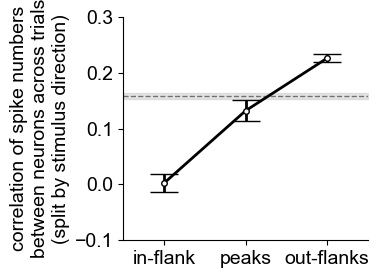

In [16]:
import scipy.stats as stats

# Convert lists to numpy arrays for easier manipulation
stim_direction_array = np.array(stim_direction_array)
noise_correlation_array = np.array(noise_correlation_array)

# Calculate means and SEMs for each group
between_corrs = noise_correlation_array[stim_direction_array==1]
peaks_corrs = noise_correlation_array[stim_direction_array==-1]
not_between_corrs = noise_correlation_array[stim_direction_array==0]

between_pairs = list(set([neuron_ids_array[i] for i in np.where(stim_direction_array==1)[0]]))
peaks_pairs = list(set([neuron_ids_array[i] for i in np.where(stim_direction_array==-1)[0]]))
not_between_pairs = list(set([neuron_ids_array[i] for i in np.where(stim_direction_array==0)[0]]))

means = [np.mean(between_corrs), np.mean(peaks_corrs), np.mean(not_between_corrs)]
sems = [stats.sem(between_corrs), stats.sem(peaks_corrs), stats.sem(not_between_corrs)]

# Calculate p-values using two-sided t-test and Mann-Whitney U test against 0
p_values_t = [stats.ttest_1samp(between_corrs, 0, alternative='two-sided').pvalue,
            stats.ttest_1samp(peaks_corrs, 0, alternative='two-sided').pvalue,
            stats.ttest_1samp(not_between_corrs, 0, alternative='two-sided').pvalue]

p_values_u = [stats.mannwhitneyu(between_corrs, np.zeros_like(between_corrs), alternative='two-sided').pvalue,
            stats.mannwhitneyu(peaks_corrs, np.zeros_like(peaks_corrs), alternative='two-sided').pvalue,
            stats.mannwhitneyu(not_between_corrs, np.zeros_like(not_between_corrs), alternative='two-sided').pvalue]

print("P-values (two-sided tests against 0):")
print(f"In-Flank (n={len(between_pairs)} pairs): t-test p={p_values_t[0]:.3e}, U-test p={p_values_u[0]:.3e}")
print(f"Peaks (n={len(peaks_pairs)} pairs): t-test p={p_values_t[1]:.3e}, U-test p={p_values_u[1]:.3e}")
print(f"Out-Flanks (n={len(not_between_pairs)} pairs): t-test p={p_values_t[2]:.3e}, U-test p={p_values_u[2]:.3e}")

# Calculate p-values for between-group comparisons using one-sided t-test and Mann-Whitney U test
p_between_peaks_t = stats.ttest_ind(between_corrs, peaks_corrs, alternative='less').pvalue
p_peaks_notbetween_t = stats.ttest_ind(peaks_corrs, not_between_corrs, alternative='less').pvalue

p_between_peaks_u = stats.mannwhitneyu(between_corrs, peaks_corrs, alternative='less').pvalue
p_peaks_notbetween_u = stats.mannwhitneyu(peaks_corrs, not_between_corrs, alternative='less').pvalue

print("\nOne-sided tests between groups:")
print(f"In-Flank < Peaks: t-test p={p_between_peaks_t:.3e}, U-test p={p_between_peaks_u:.3e}")
print(f"Peaks < Out-Flanks: t-test p={p_peaks_notbetween_t:.3e}, U-test p={p_peaks_notbetween_u:.3e}")

# Calculate p-values comparing to overall fixation mean
p_peaks_vs_fixation_t = stats.ttest_ind(peaks_corrs, noise_correlation_array_fixation, alternative='two-sided').pvalue
p_notbetween_vs_fixation_t = stats.ttest_ind(not_between_corrs, noise_correlation_array_fixation, alternative='greater').pvalue
p_between_vs_fixation_t = stats.ttest_ind(between_corrs, noise_correlation_array_fixation, alternative='less').pvalue

p_peaks_vs_fixation_u = stats.mannwhitneyu(peaks_corrs, noise_correlation_array_fixation, alternative='two-sided').pvalue
p_notbetween_vs_fixation_u = stats.mannwhitneyu(not_between_corrs, noise_correlation_array_fixation, alternative='greater').pvalue
p_between_vs_fixation_u = stats.mannwhitneyu(between_corrs, noise_correlation_array_fixation, alternative='less').pvalue

print("\nTests against fixation array:")
print(f"In-Flank vs fixation (one-sided): t-test p={p_between_vs_fixation_t:.3e}, U-test p={p_between_vs_fixation_u:.3e}")
print(f"Peaks vs fixation (two-sided): t-test p={p_peaks_vs_fixation_t:.3e}, U-test p={p_peaks_vs_fixation_u:.3e}")
print(f"Out-Flanks vs fixation (one-sided): t-test p={p_notbetween_vs_fixation_t:.3e}, U-test p={p_notbetween_vs_fixation_u:.3e}")

# Create the plot
fig, ax = plt.subplots(figsize=(4, 3))
plt.rc('font', **{'family': 'Arial', 'weight': 'normal', 'size': 14})
x = np.arange(3)

# Plot individual points with jitter
jitter = np.random.normal(0, 0.07, len(noise_correlation_array))
plt.ylim(-0.1, 0.3)
plt.xlim(-0.5, 2.5)

# Add horizontal line at overall_mean_fixation and shaded region for SEM
ax.axhline(y=overall_mean_fixation, color='black', linestyle='--', alpha=.5, linewidth=1)
ax.fill_between([-0.5, 2.5], 
                overall_mean_fixation - overall_sem_fixation,
                overall_mean_fixation + overall_sem_fixation,
                color='gray', alpha=0.2)

# Plot line with error bars
ax.errorbar(x, means, yerr=sems, capsize=10, color='black', marker='.', markersize=8,
           markerfacecolor='white', markeredgecolor='black', linewidth=2)

# Customize the plot
ax.set_xticks(x)
ax.set_xticklabels(['in-flank', 'peaks', 'out-flanks'])
ax.set_ylabel('correlation of spike numbers\nbetween neurons across trials\n(split by stimulus direction)')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('paper_figures/noise_correlation_between_flank_and_peaks.pdf', bbox_inches='tight')
